**Example A:**
  -We are going to use 2 layers
  -optimizer we are going to use SGD
  -We are going to use without Normalization

**Example B:**
  -We are going to use 3 layers
  -optimizer we are going to use Adam
  -We are going to use without Normalization

**Example C:**
  -We are going to use 2 layers
  -optimizer we are going to use Adam
  -e are going to use with Normalization and standardizatio

In [34]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [35]:
insurance=pd.read_csv('/content/sample_data/insurance_data.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
insurance_one_hot=pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False


In [37]:
x=insurance_one_hot.drop('charges',axis=1)
y=insurance_one_hot['charges']

In [38]:
print('Features are: ')
x.head()

Features are: 


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,True
1,18,33.770,1,False,True,True,False,False,True,False
2,28,33.000,3,False,True,True,False,False,True,False
3,33,22.705,0,False,True,True,False,True,False,False
4,32,28.880,0,False,True,True,False,True,False,False


In [39]:
print('Charges')
y.head()

Charges


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [40]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [41]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

In [42]:
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

In [43]:
insurance_model.fit(x_train,y_train,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step - loss: 8520.2705 - mae: 8520.2705
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8516.1738 - mae: 8516.1738
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 8514.5742 - mae: 8514.5742
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 8513.6377 - mae: 8513.6377
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 8512.5400 - mae: 8512.5400
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 8510.6143 - mae: 8510.6143
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 8506.8574 - mae: 8506.8574
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 8499.3721 - mae: 8499.3721
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 8484.3965 - mae: 8484.3965
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 8454.4092 - mae: 8454.4092
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 8394.3467 - mae: 8394.3467
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss

In [44]:
insurance_model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 7761.1836 - mae: 7761.1836


[7761.18359375, 7761.18359375]

In [45]:
tf.random.set_seed(42)
insurance_model=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])
history_model_2=insurance_model.fit(x_train,y_train,epochs=150,verbose=0)

In [46]:
insurance_model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 7714.7798 - mae: 7714.7798


[7714.77978515625, 7714.77978515625]

In [47]:
insurance_model_2_loss,insurance_model_2_mae=insurance_model.evaluate(x_test,y_test)
print('Loss',insurance_model_2_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7714.7798 - mae: 7714.7798
Loss 7714.77978515625


/tmp/ipython-input-3221017223.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


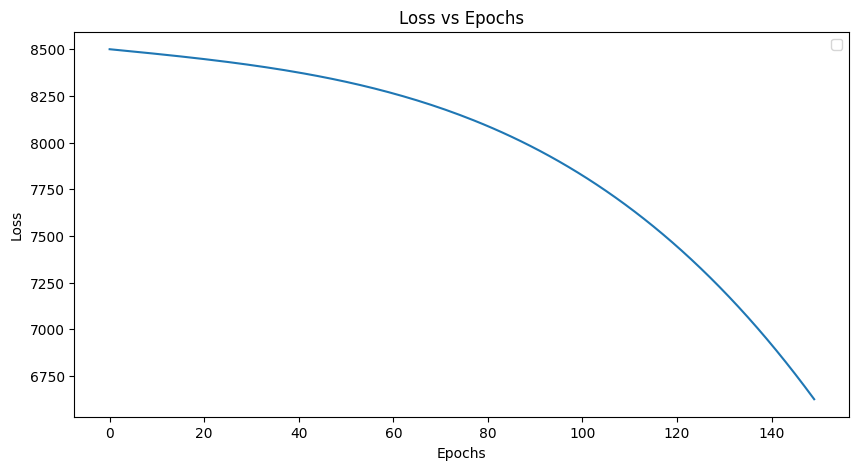

In [48]:
plt.figure(figsize=(10,5))
plt.plot(history_model_2.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

Exercise - c

In [49]:
ct=make_column_transformer(
    (MinMaxScaler(),['age','bmi','children']),
    (OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region'])
)

In [50]:
x=insurance.drop('charges',axis=1)
y=insurance['charges']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
ct.fit(x_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [53]:
x_train_normal=ct.transform(x_train)
x_test_normal=ct.transform(x_test)

In [56]:
x_train #non normalized data (original)

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [57]:
x_train_normal #normalized data

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [58]:
print('X-train Shape',x_train.shape)
print('X-train Normal Shape',x_train_normal.shape)

X-train Shape (4, 6)
X-train Normal Shape (4, 8)


In [60]:
tf.random.set_seed(42)
insurance_model_3=tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model_3.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])
history_model_3=insurance_model_3.fit(x_train_normal,y_train,epochs=150,verbose=0)

In [61]:
insurance_model_3.evaluate(x_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step - loss: 9248.5547 - mae: 9248.5547


[9248.5546875, 9248.5546875]

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history_model_3.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()